In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split #For splitting the data into train & test
from sklearn.linear_model import LinearRegression #Linear regression model
from sklearn.metrics import mean_squared_error #Metric for regression MSE
import numpy as np

import matplotlib.pyplot as plt

In [22]:
df=pd.read_csv("./testing/dataset_21.csv")
df.head()

,CUSTOM.date [local],CUSTOM.updateTime [local],OSD.flyTime,OSD.flyTime [s],OSD.latitude,OSD.longitude,OSD.height [ft],OSD.heightMax [ft],OSD.vpsHeight [ft],OSD.altitude [ft],...,SERIAL.flightController,SERIAL.camera,SERIAL.gimbal,SERIAL.rc,SERIAL.battery,APPGPS.latitude,APPGPS.longitude,APPGPS.accuracy,APP.tip,APP.warning
0,2/14/2024,07:26.0,0m 0.0s,0.0,6.974255,79.914009,0.0,0.0,0.3,50,...,1SDCH7G0169R0K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Flight mode changed to Starting Motors.,NaN
1,2/14/2024,07:26.1,0m 0.1s,0.1,6.974255,79.914008,0.0,0.0,0.3,50,...,1SDCH7G0169R0K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2/14/2024,07:26.2,0m 0.2s,0.2,6.974255,79.914008,0.0,0.0,0.3,50,...,1SDCH7G0169R0K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2/14/2024,07:26.3,0m 0.3s,0.3,6.974255,79.914008,0.0,0.0,0.3,50,...,1SDCH7G0169R0K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2/14/2024,07:26.4,0m 0.4s,0.4,6.974255,79.914008,0.0,0.0,0.3,50,...,1SDCH7G0169R0K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# List of important parameters to keep
important_parameters = [
    'CUSTOM.updateTime [local]',
    'OSD.latitude', 'OSD.longitude', 'OSD.height [ft]', 'OSD.hSpeed [MPH]',
    'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder'
]

# Keep only the important parameters
df = df[important_parameters]

In [24]:
df.shape

(899, 9)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Assuming 'your_file.csv' is the name of your CSV file
df = pd.read_csv('data.csv')

# Selecting relevant features and target variable
features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder', 'RC.mode']
target = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  # You can choose other strategies like 'median' or 'most_frequent'
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Handling missing values in target variables (if any)
# For simplicity, let's drop rows with missing target values
y_train = y_train.dropna().reset_index(drop=True)
X_train_imputed = X_train_imputed[y_train.index]

# Creating and training the Random Forest Regression model for longitude
model_longitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_longitude.fit(X_train_imputed, y_train['OSD.longitude'])

# Creating and training the Random Forest Regression model for latitude
model_latitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_latitude.fit(X_train_imputed, y_train['OSD.latitude'])

# Creating and training the Random Forest Regression model for altitude
model_altitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_altitude.fit(X_train_imputed, y_train['OSD.height [ft]'])

# Making predictions on the test set
longitude_pred = model_longitude.predict(X_test_imputed)
latitude_pred = model_latitude.predict(X_test_imputed)
altitude_pred = model_altitude.predict(X_test_imputed)

# Evaluating the models
mse_longitude = mean_squared_error(y_test['OSD.longitude'], longitude_pred)
r2_longitude = r2_score(y_test['OSD.longitude'], longitude_pred)

mse_latitude = mean_squared_error(y_test['OSD.latitude'], latitude_pred)
r2_latitude = r2_score(y_test['OSD.latitude'], latitude_pred)

mse_altitude = mean_squared_error(y_test['OSD.height [ft]'], altitude_pred)
r2_altitude = r2_score(y_test['OSD.height [ft]'], altitude_pred)

print(f'Mean Squared Error (Longitude): {mse_longitude}, R-squared (Longitude): {r2_longitude}')
print(f'Mean Squared Error (Latitude): {mse_latitude}, R-squared (Latitude): {r2_latitude}')
print(f'Mean Squared Error (Altitude): {mse_altitude}, R-squared (Altitude): {r2_altitude}')


Mean Squared Error (Longitude): 1.4170605645365965e-10, R-squared (Longitude): 0.3852416279335438
Mean Squared Error (Latitude): 4.6119519702616476e-10, R-squared (Latitude): 0.27060349504914627
Mean Squared Error (Altitude): 0.4726949882014122, R-squared (Altitude): 0.45662397286604417


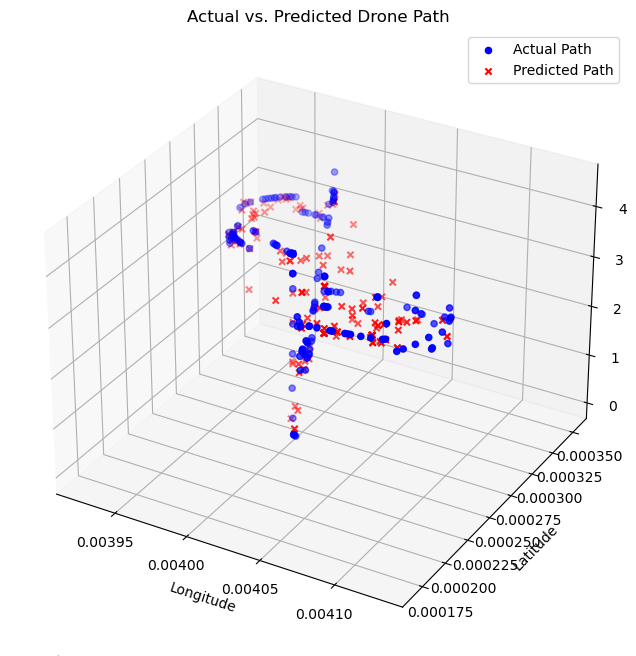

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

# Selecting relevant features and target variable
features = ['RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
target = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Handling missing values in target variables (if any)
y_train = y_train.dropna().reset_index(drop=True)
X_train_imputed = X_train_imputed[y_train.index]

# Creating and training the Random Forest Regression model for longitude
model_longitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_longitude.fit(X_train_imputed, y_train['OSD.longitude'])

# Creating and training the Random Forest Regression model for latitude
model_latitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_latitude.fit(X_train_imputed, y_train['OSD.latitude'])

# Creating and training the Random Forest Regression model for altitude
model_altitude = RandomForestRegressor(n_estimators=100, random_state=42)
model_altitude.fit(X_train_imputed, y_train['OSD.height [ft]'])

# Making predictions on the test set
longitude_pred = model_longitude.predict(X_test_imputed)
latitude_pred = model_latitude.predict(X_test_imputed)
altitude_pred = model_altitude.predict(X_test_imputed)

# Create a 3D plot for the predicted drone path
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual drone path
ax.scatter(y_test['OSD.longitude'], y_test['OSD.latitude'], y_test['OSD.height [ft]'], c='blue', marker='o', label='Actual Path')

# Plot the predicted drone path
ax.scatter(longitude_pred, latitude_pred, altitude_pred, c='red', marker='x', label='Predicted Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('Actual vs. Predicted Drone Path')
ax.legend()

# Show the plot
plt.show()


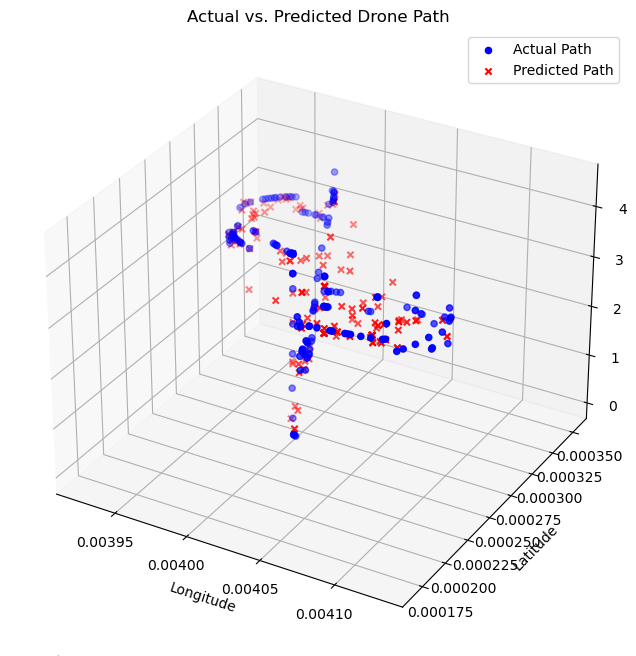

In [45]:
# Create a 3D plot for the predicted drone path
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual drone path with larger markers
ax.scatter(y_test['OSD.longitude'], y_test['OSD.latitude'], y_test['OSD.height [ft]'], c='blue', marker='o', s=20, label='Actual Path')

# Plot the predicted drone path with larger markers
ax.scatter(longitude_pred, latitude_pred, altitude_pred, c='red', marker='x', s=20, label='Predicted Path')

# Customize the plot
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Altitude (ft)')
ax.set_title('Actual vs. Predicted Drone Path')
ax.legend()

# Show the plot
plt.show()


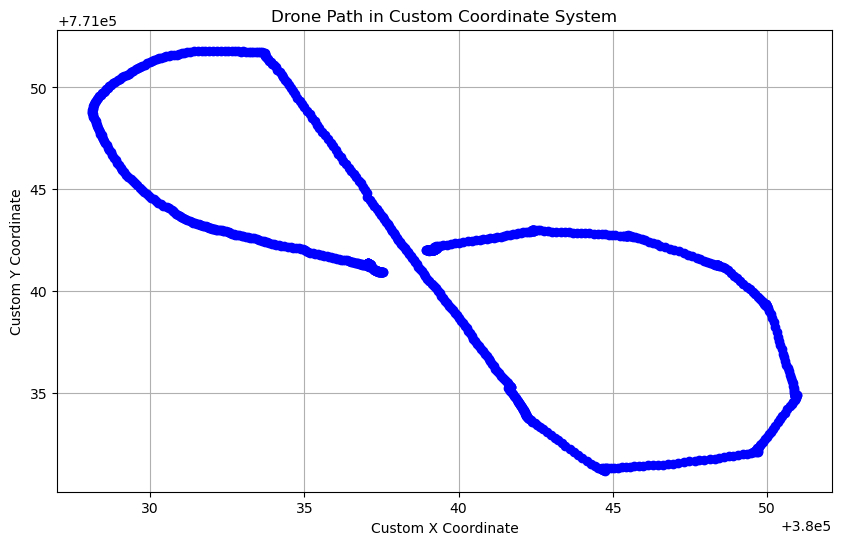

In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import utm

def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Load the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Convert latitude and longitude to another coordinate system (e.g., UTM)
def convert_to_coordinate_system(row):
    # Convert latitude and longitude to UTM coordinates
    utm_x, utm_y, zone_number, zone_letter = utm.from_latlon(row['OSD.latitude'], row['OSD.longitude'])
    
    # Alternatively, you can use any other projection method here
    # Example:
    # other_x = some_projection_method(row['OSD.latitude'], row['OSD.longitude'])
    # other_y = some_projection_method(row['OSD.latitude'], row['OSD.longitude'])
    
    return pd.Series([utm_x, utm_y])  # Return the converted coordinates

# Apply the conversion function to each row and create new columns for the converted coordinates
df_test_custom[['Custom_X', 'Custom_Y']] = df_test_custom.apply(convert_to_coordinate_system, axis=1)

# Create a 2D plot for the drone path using the converted coordinates
plt.figure(figsize=(10, 6))
plt.plot(df_test_custom['Custom_X'], df_test_custom['Custom_Y'], marker='o', linestyle='-', color='blue')
plt.xlabel('Custom X Coordinate')
plt.ylabel('Custom Y Coordinate')
plt.title('Drone Path in Custom Coordinate System')
plt.grid(True)
plt.show()


In [40]:
from sklearn.preprocessing import StandardScaler

# Load the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# List of important parameters to keep
important_parameters = [
    'OSD.flyTime',
    'OSD.latitude', 'OSD.longitude', 'OSD.height [ft]', 'OSD.hSpeed [MPH]',
    'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder'
]

# Keep only the important parameters
df_test_custom = df_test_custom[important_parameters]

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Convert latitude and longitude to UTM coordinates
def convert_to_utm(row):
    utm_x, utm_y, _, _ = utm.from_latlon(row['OSD.latitude'], row['OSD.longitude'])
    return pd.Series([utm_x, utm_y])

df_test_custom[['OSD.latitude', 'OSD.longitude']] = df_test_custom.apply(convert_to_utm, axis=1)

# Fit the scaler on the training data
scaler = StandardScaler()
scaler.fit(X_train)

# Normalize the custom test data
df_test_custom_scaled = scaler.transform(df_test_custom)

# Apply rank transformation to each selected feature
for feature in df_test_custom.columns:
    df_test_custom[feature] = df_test_custom[feature].rank()

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='red', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- OSD.flyTime
- OSD.hSpeed [MPH]
- OSD.height [ft]
- OSD.latitude
- OSD.longitude
